# Homework 2: VAE and VQ-VAE

## Task 1: Theory (5 pts)

### Problem 1: IWAE theory (2 pts)

Variational inference is based on the ELBO objective:
$$
    \mathcal{L} (\boldsymbol{\phi}, \boldsymbol{\theta})  = \mathbb{E}_{\mathbf{z} \sim q(\mathbf{z} | \mathbf{x})} \log \left( \frac{p(\mathbf{x}, \mathbf{z} | \boldsymbol{\theta})}{q(\mathbf{z}| \mathbf{x}, \boldsymbol{\phi})} \right) \rightarrow \max_{\boldsymbol{\phi}, \boldsymbol{\theta}}.
$$
ELBO is a lower bound of the log-likelihood. However if the gap between ELBO and log-likelihood is large, then our model is not optimal. In this task we discuss the way, how to improve the lower bound.

The improvement was introduced in the [IWAE](https://arxiv.org/abs/1509.00519) model. This model introduces the improved version of the variational lower bound (ELBO):

$$
    \mathcal{L}_K (\boldsymbol{\phi}, \boldsymbol{\theta}) = \mathbb{E}_{\mathbf{z}_1, \dots, \mathbf{z}_K \sim q(\mathbf{z} | \mathbf{x}, \boldsymbol{\phi})} \log \left( \frac{1}{K}\sum_{k=1}^K\frac{p(\mathbf{x}, \mathbf{z}_k | \boldsymbol{\theta})}{q(\mathbf{z}_k| \mathbf{x}, \boldsymbol{\phi})} \right) \rightarrow \max_{\boldsymbol{\phi}, \boldsymbol{\theta}}.
$$

Note, that the difference with the original ELBO is the sum over $K$ different latent vectors $\mathbf{z}_k$.

Moreover we can rewrite ELBO in the following form:

$$
    \mathcal{L} (\boldsymbol{\phi}, \boldsymbol{\theta}) = \frac{1}{K} \sum_{k=1}^K\mathcal{L} (\boldsymbol{\phi}, \boldsymbol{\theta}) = \frac{1}{K} \sum_{k=1}^K \mathbb{E}_{\mathbf{z}_k \sim q(\mathbf{z} | \mathbf{x}, \boldsymbol{\phi})} \log \left( \frac{p(\mathbf{x}, \mathbf{z}_k | \boldsymbol{\theta})}{q(\mathbf{z}_k| \mathbf{x}, \boldsymbol{\phi})} \right) = \frac{1}{K}  \mathbb{E}_{\mathbf{z}_k \sim q(\mathbf{z} | \mathbf{x}, \boldsymbol{\phi})} \sum_{k=1}^K \log \left( \frac{p(\mathbf{x}, \mathbf{z}_k | \boldsymbol{\theta})}{q(\mathbf{z}_k| \mathbf{x}, \boldsymbol{\phi})} \right).
$$
Here we see that the only difference between these two objectives ($\mathcal{L} (\boldsymbol{\phi}, \boldsymbol{\theta})$ and $\mathcal{L}_K (\boldsymbol{\phi}, \boldsymbol{\theta})$) is the order of sum and logarithm.

Our task here is two proof that the objective $\mathcal{L}_K (\boldsymbol{\phi}, \boldsymbol{\theta})$ is also a lower bound of log-likelihood and this lower bound is better than the initial ELBO.

We have to prove the following facts:

1. $\log p(\mathbf{x} | \boldsymbol{\theta}) \geq \mathcal{L}_K (\boldsymbol{\phi}, \boldsymbol{\theta}) \geq \mathcal{L}_M (\boldsymbol{\phi}, \boldsymbol{\theta}), \quad \text{for } K \geq M$;
2.  $\log p(\mathbf{x} | \boldsymbol{\theta}) = \lim_{K \rightarrow \infty} \mathcal{L}_K (\boldsymbol{\phi}, \boldsymbol{\theta})$ if $\frac{p(\mathbf{x}, \mathbf{z} | \boldsymbol{\theta})}{q(\mathbf{z} | \mathbf{x}, \boldsymbol{\phi})}$ is bounded.

**Hints:**
1. First part of the theorem.

    (a) Use the following equation inside the logarithm of $\mathcal{L}_K (q, \boldsymbol{\theta})$
$$
    \frac{a_1 + \dots + a_K}{K} = \mathbb{E}_{k_1, \dots, k_M} \frac{a_{k_1} + \dots + a_{k_M}}{M},
$$

Here $k_1, \dots, k_M$ are distinct indices sampled from $U[1, K]$.

    (b) Apply Jensen' inequality.
3. Second part of the theorem: use the Law of large numbers.


### Solution

Let $g(\mathbf{z}) = \frac{p(\mathbf{x}, \mathbf{z} | \boldsymbol{\theta})}{q(\mathbf{z}| \mathbf{x}, \boldsymbol{\phi})}$

1. 
first inequality:
$$
    \mathcal{L}_K (\boldsymbol{\phi}, \boldsymbol{\theta}) = \mathbb{E}_{\mathbf{z}_1, \dots, \mathbf{z}_K \sim q(\mathbf{z} | \mathbf{x}, \boldsymbol{\phi})} \log \left( \frac{1}{K} \sum_{k=1}^{K} g(\mathbf{z}_k) \right) \overset{\text{Jensen}}{\leq} \log \left( \mathbb{E}_{\mathbf{z}_1, \dots, \mathbf{z}_K \sim q(\mathbf{z} | \mathbf{x}, \boldsymbol{\phi})} \frac{1}{K} \sum_{k=1}^{K} g(\mathbf{z}_k) \right) = \log \left( \mathbb{E}_{\mathbf{z} \sim q(\mathbf{z} | \mathbf{x}, \boldsymbol{\phi})} g(\mathbf{z}) \right) = \log \left( \int p(\mathbf{x}, \mathbf{z} | \boldsymbol{\theta}) d\mathbf{z} \right) = \log p(\mathbf{x} | \boldsymbol{\theta})
$$

second inequality:

$$
    \mathcal{L}_K (\boldsymbol{\phi}, \boldsymbol{\theta}) = \mathbb{E}_{\mathbf{z}_1, \dots, \mathbf{z}_K \sim q(\mathbf{z} | \mathbf{x}, \boldsymbol{\phi})} \log \left( \frac{1}{K} \sum_{k=1}^{K} g(\mathbf{z}_k) \right) = \mathbb{E}_{\mathbf{z}_1, \dots, \mathbf{z}_K \sim q(\mathbf{z} | \mathbf{x}, \boldsymbol{\phi})} \log \left( \mathbb{E}_{k_1, \dots, k_M} \frac{1}{M} \sum_{i=1}^{M} g(\mathbf{z}_{k_i}) \right) \overset{\text{Jensen}}{\geq} \\ \mathbb{E}_{\mathbf{z}_1, \dots, \mathbf{z}_K \sim q(\mathbf{z} | \mathbf{x}, \boldsymbol{\phi})} \mathbb{E}_{k_1, \dots, k_M} \log \left( \frac{1}{M} \sum_{i=1}^{M} g(\mathbf{z}_{k_i}) \right) = \mathbb{E}_{\mathbf{z}_1, \dots, \mathbf{z}_M \sim q(\mathbf{z} | \mathbf{x}, \boldsymbol{\phi})} \log \left( \frac{1}{M} \sum_{k=1}^{M} g(\mathbf{z}_k) \right) =  \mathcal{L}_M (\boldsymbol{\phi}, \boldsymbol{\theta})
$$

second to last equality holds because we can swap expectations due to the fact that $k_1, \dots, k_M$ are distinct and all $z_1, \ldots z_K$ are sampled independently.

2. by law of large numbers
$$
    \lim_{K \to \infty} \left( \frac{1}{K} \sum_{k=1}^{K} g(\mathbf{z}_k) \right) = \mathbb{E}_{q} g(\mathbf{z}) = \int p(\mathbf{x}, \mathbf{z} | \boldsymbol{\theta}) d\mathbf{z} = p(\mathbf{x} | \boldsymbol{\theta})
$$
So
$$
    \lim_{K \to \infty} \mathcal{L}_K (\boldsymbol{\phi}, \boldsymbol{\theta}) = \log p(\mathbf{x} | \boldsymbol{\theta})
$$


### Problem 2: Gaussian VAE (1 pt)

Suppose that we have a random variable $x \in \mathbb{R}$ and a latent variable $z \in \mathbb{R}$ such that
$$
    x \sim \pi(x) = \mathcal{N}(\mu, 1), \quad z \sim p(z) = \mathcal{N}(0, 1).
$$

Let consider trivial VAE model with the following encoder $q(z | x, \phi)$ and decoder $p(x | z, \theta)$
\begin{align*}
    q(z | x, \phi) &= \mathcal{N}(x + \phi, 1); \\
    \quad p(x | z, \theta) &= \mathcal{N}(z + \theta, 1).
\end{align*}

Your task here to find the optimal parameters $\phi$ and $\theta$ using ELBO:
$$
    \mathbb{E}_{\pi(x)} \mathcal{L}_{\phi, \theta}(x) = \mathbb{E}_{\pi(x)} \left[\mathbb{E}_{q(z | x, \phi)} \log p(x | z, \theta) - KL(q(z | x, \phi) || p(z))\right].
$$

### Solution

first term:

Let $\epsilon \sim \mathcal{N}(0, 1)$, then $z = x + \phi + \epsilon$

$$
    \mathbb{E}_{q(z | x, \phi)} \log p(x | z, \theta) = \mathbb{E}_{q(z | x, \phi)} \left( -\frac{1}{2} \left( (x - z - \theta)^2 + \log 2\pi \right) \right) = \mathbb{E}_{\epsilon \sim \mathcal{N}(0, 1)} \left( -\frac{1}{2} \left( (\phi + \epsilon + \theta)^2 + \log 2\pi \right) \right)
$$ 

In [1]:
import sympy as sp

eps, phi, theta = sp.symbols(r"\epsilon, \phi, \theta")
pdf_gauss = sp.exp(-(eps**2) / 2) / sp.sqrt(2 * sp.pi)
expr1 = -1/2 * ((phi + eps + theta)**2 + sp.log(2 * sp.pi))
sp.integrate(expr1 * pdf_gauss, (eps, -sp.oo, sp.oo))

-0.5*\phi**2 - 1.0*\phi*\theta - 0.5*\theta**2 - 0.5*log(pi) - 0.5 - 0.5*log(2)

$$
    = -\frac{1}{2} \left( (\phi + \theta)^2 + 1 + \log 2\pi \right)
$$


second term:

$$
    -KL (\mathcal{N}(x + \phi, 1) || \mathcal{N}(0, 1)) = -\frac{1}{2} (x + \phi)^2
$$

compute expectation over $\pi(x)$:

$$
    \mathbb{E}_{\pi(x)} \mathcal{L}_{\phi, \theta}(x) = \mathbb{E}_{\pi(x)} \left( -\frac{1}{2} \left( (\phi + \theta)^2 + 1 + \log 2\pi \right) -\frac{1}{2} (x + \phi)^2 \right)
$$

In [2]:
x, mu = sp.symbols(r"x, \mu")
expr_comb = -1 / 2 * ((phi + theta) ** 2 + 1 + sp.log(2 * sp.pi)) - 1 / 2 * (x + phi) ** 2
pdf_pi = sp.exp(-((x - mu)**2) / 2) / sp.sqrt(2 * sp.pi)

sp.simplify(sp.integrate(expr_comb * pdf_pi, (x, -sp.oo, sp.oo)))

-0.5*\mu**2 - 1.0*\mu*\phi - 1.0*\phi**2 - 1.0*\phi*\theta - 0.5*\theta**2 - 1.0 + log(0.707106781186548/pi**0.5)

$$
    = -\frac{1}{2} \left( (\phi + \theta)^2 + (\mu + \phi)^2 + C \right)
$$

reaches its maximum $-\frac{1}{2} C$ when $\phi = -\mu$ and $\theta = \mu$

### Problem 3: ELBO surgery (2 pts)

At the lecture we proved the [ELBO surgery](https://www.cs.columbia.edu/~blei/fogm/2020F/readings/HoffmanJohnson2016.pdf) theorem:
$$
    \frac{1}{n} \sum_{i=1}^n KL(q(\mathbf{z} | \mathbf{x}_i) || p(\mathbf{z})) = KL(q_{\text{agg}}(\mathbf{z}) || p(\mathbf{z})) + \mathbb{I}_{q} [\mathbf{x}, \mathbf{z}],
$$
where the first term is $KL(q_{\text{agg}}(\mathbf{z}) || p(\mathbf{z}))$ includes the aggregated posterior distribution $q_{\text{agg}}(\mathbf{z})$ and the prior distribution $p(\mathbf{z})$. Our goal now is to deal with the second term. At the lecture, the second term was equal to:

$$
    \mathbb{I}_{q} [\mathbf{x}, \mathbf{z}] = \frac{1}{n}\sum_{i=1}^n KL(q(\mathbf{z} | \mathbf{x}_i) || q_{\text{agg}}(\mathbf{z})).
$$
In fact, this is a mutual information between $\mathbf{x}$ and $\mathbf{z}$ on the empirical distribution of data and the distribution of $q(\mathbf{z} | \mathbf{x})$. Let treat the index of the sample $i$ as a random variable.
$$
    q(i, \mathbf{z}) = q(i) q(\mathbf{z} | i); \quad p(i, \mathbf{z}) = p(i) p(\mathbf{z}); \quad
    q(i) = p(i) = \frac{1}{n}.
$$
$$
    \quad q(\mathbf{z} | i) = q(\mathbf{z} | \mathbf{x}_i) \quad q_{\text{agg}}(\mathbf{z}) = \sum_{i=1}^n q(i, \mathbf{z}) = \frac{1}{n} \sum_{i=1}^n q(\mathbf{z} | \mathbf{x}_i);  
$$
Mutual information is a measure of independence between two random variables.
$$
	\mathbb{I}_{q} [\mathbf{x}, \mathbf{z}] = \mathbb{E}_{q(i, \mathbf{z})} \log \frac{q(i, \mathbf{z})}{q(i)q_{\text{agg}}(\mathbf{z})}.
$$
Prove that 2 expressions for the mutual information are equal to each other.

### Solution

$$
    \mathbb{I}_{q} [\mathbf{x}, \mathbf{z}] = \mathbb{E}_{q(i, \mathbf{z})} \log \frac{q(i, \mathbf{z})}{q(i)q_{\text{agg}}(\mathbf{z})} = \int \int q(i, \mathbf{z}) \log \frac{q(\mathbf{z} | i)}{q_{\text{agg}}(\mathbf{z})} dz di
$$
outer integral is actually a sum over all samples:

$$
    = \sum_{i=1}^n \int \frac{1}{n} q(\mathbf{z} | i) \log \frac{q(\mathbf{z} | i)}{q_{\text{agg}}(\mathbf{z})} dz = \frac{1}{n} \sum_{i=1}^n \int q(\mathbf{z} | i) \log \frac{q(\mathbf{z} | i)}{q_{\text{agg}}(\mathbf{z})} dz = \frac{1}{n}\sum_{i=1}^n KL(q(\mathbf{z} | \mathbf{x}_i) || q_{\text{agg}}(\mathbf{z}))
$$

where in last equality we used $q(\mathbf{z} | i) = q(\mathbf{z} | \mathbf{x}_i)$

Now it time to move on to practical part of homework.

In our course we will use a small util [package](https://github.com/r-isachenko/dgm_utils) with some usefull functions for loading and visualizing the images and training curves. In each homework there will be a cell with installing this package. Please read carefully the sources of the functions from this package. It could help you to solve the tasks.

In [1]:
COMMIT_HASH = "e0be9c3e4ac3eb84ca8f7cd27fd0ba6049ad0fa7"
!if [ -d dgm_utils ]; then rm -Rf dgm_utils; fi
!git clone https://github.com/r-isachenko/dgm_utils.git
%cd dgm_utils
!git checkout {COMMIT_HASH}
!pip install ./
%cd ./..
!rm -Rf dgm_utils

Cloning into 'dgm_utils'...
remote: Enumerating objects: 219, done.
remote: Counting objects: 100% (219/219), done.
remote: Compressing objects: 100% (167/167), done.
remote: Total 219 (delta 143), reused 99 (delta 52), pack-reused 0 (from 0)
Receiving objects: 100% (219/219), 52.84 KiB | 4.40 MiB/s, done.
Resolving deltas: 100% (143/143), done.
/content/dgm_utils
Note: switching to 'e0be9c3e4ac3eb84ca8f7cd27fd0ba6049ad0fa7'.

You are in 'detached HEAD' state. You can look around, make experimental
changes and commit them, and you can discard any commits you make in this
state without impacting any branches by switching back to a branch.

If you want to create a new branch to retain commits you create, you may
do so (now or later) by using -c with the switch command. Example:

  git switch -c <new-branch-name>

Or undo this operation with:

  git switch -

Turn off this advice by setting config variable advice.detachedHead to false

HEAD is now at e0be9c3 Add grad clipping
Processing /

In [2]:
from dgm_utils import train_model
from dgm_utils import show_samples, visualize_images, load_dataset
from dgm_utils import BaseModel

In [4]:
import numpy as np
from typing import Tuple, Optional

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data as data

if torch.cuda.is_available():
    DEVICE = "cuda"
    print('GPU found :)')
else:
    DEVICE = "cpu"
    print('GPU not found :(')

GPU found :)


## Task 2: ViT Model (2 pts) 

We begin by introducing a **Vision Transformer (ViT)** architecture that will serve as the encoder and decoder for both the VAE and VQ-VAE generative models. In contrast to conventional CNN-based approaches that process an image as a 2D grid of pixels using local convolutional filters, ViT partitions the image into non-overlapping patches and maps each patch to a vector in a learnable embedding space. This representation allows us to reinterpret the image as a sequence of tokens, making it compatible with Transformer architectures originally designed for sequential data processing.

Let us begin by defining the Transformer block, which serves as the fundamental building component of the ViT architecture. It is implemented as follows:
\begin{gather}
    \mathbf{n}^l = \text{layer\_norm}_1\left(\mathbf{h}^l\right), \notag \\
    \mathbf{a}^l = \mathbf{h}^l + \text{multihead\_attention}\left(\mathbf{n}^l\right), \notag \\
    \mathbf{h}^{l+1} = \mathbf{a}^l + \text{MLP}\left(\text{layer\_norm}_2\left(a^l\right)\right). \notag
\end{gather}

The $l^{\text{th}}$ block receives a tensor $\mathbf{h}^l$ of shape `(batch_size, patch_num, emb_dim)`, where `emb_dim` is a hyperparameter that defines the dimensionality of the embeddings.

In [5]:
class TransformerBlock(nn.Module):
    def __init__(
            self, 
            embed_dim: int, 
            num_heads: int,
            # this is for conviniance
            attention_class: nn.Module = nn.MultiheadAttention,
        ) -> None:
        super().__init__()
        assert embed_dim % num_heads == 0

        self.ln1 = nn.LayerNorm(embed_dim)
        self.mha = attention_class(
            embed_dim, num_heads, batch_first=True
        )
        self.ln2 = nn.LayerNorm(embed_dim)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, 4 * embed_dim),
            nn.GELU(),
            nn.Linear(4 * embed_dim, embed_dim),
        )
        # ====
        # your code
        # define basic layers of Transformer:
        # 1) LayerNorm (https://docs.pytorch.org/docs/stable/generated/torch.nn.LayerNorm.html)
        # 2) some MLP

        # ====

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # ====
        # your code
        # here you have to implement formulas that described above.

        # ====

        x_normed = self.ln1(x)
        x = x + self.mha(x_normed, x_normed, x_normed)[0]
        return x + self.mlp(self.ln2(x))


def test_transformer_block() -> None:
    block = TransformerBlock(embed_dim=12, num_heads=4)
    x = torch.zeros(4, 28, 12)
    assert x.shape == block(x).shape

test_transformer_block()

Next, we define two projection layers that map images to sequences of flattened patches and reconstruct them back to the image space.

In [6]:
from einops import rearrange


class PatchProjection(nn.Module):
    def __init__(
        self,
        num_channels: int,
        dim: int,
        patch_shape: Tuple[int, int],
    ):
        super().__init__()
        self.proj = nn.Conv2d(num_channels, dim, kernel_size=patch_shape, stride=patch_shape)

    def forward(self, x: torch.Tensor):
        # ====
        # your code
        # do following
        # 1) convolution with kernel_size=stride=patch_shape:
        #      splits the image into non-overlapping patches
        #      and projects each patch to `dim`
        #      (B, C, H, W) -> (B, dim, H', W'),
        #      where H' = H // P_h and W' = W // P_w
        # 2) flatten patch grid to tokens:
        #      (B, dim, H', W') -> (B, dim, N), where N = H' * W'
        # 3) transpose to token-major format:
        #      (B, dim, N) -> (B, N, dim)

        # ====
        x = self.proj(x)
        x = rearrange(x, "b c h w -> b (h w) c")
        return x


class ImageProjection(nn.Module):
    def __init__(
        self,
        dim: int,
        num_channels: int,
        patch_shape: Tuple[int, int],
        image_shape: Tuple[int, int],
    ):
        super().__init__()
        self.num_channels = num_channels
        self.patch_shape = patch_shape
        self.image_shape = image_shape
        assert image_shape[0] % patch_shape[0] == 0 and image_shape[1] % patch_shape[1] == 0, "Image dimensions must be divisible by the patch size."

        patch_dim = num_channels * patch_shape[0] * patch_shape[1]
        self.proj = nn.Linear(dim, patch_dim)

        self.refine = nn.Sequential(
            *[
                nn.Conv2d(num_channels, 2 * num_channels, kernel_size=3, padding=1),
                nn.GELU(),
                nn.Conv2d(2 * num_channels, 2 * num_channels, kernel_size=3, padding=1),
                nn.GELU(),
                nn.Conv2d(2 * num_channels, num_channels, kernel_size=1),
            ]
        )

    def forward(self, x: torch.Tensor):
        # ====
        # your code
        # 1) project each token back to patch pixels:
        #      (B, N, dim) -> (B, N, C * P_h * P_w)
        # 2) restore patch grid and patch shape:
        #      (B, N, C * P_h * P_w) -> (B, H', W', P_h, P_w, C)
        # 3) move channels first and interleave grid with patch pixels:
        #      (B, H', W', P_h, P_w, C) -> (B, C, H', P_h, W', P_w)
        # 4) Merge dimensions to reconstruct the image:
        #      (B, C, H', P_h, W', P_w) -> (B, C, H, W)
        # 5) apply CNN to reduce blocky patch artifacts

        # ====
        x = self.proj(x)
        x = rearrange(
            x,
            "b (h w) (c ph pw) -> b c (h ph) (w pw)",
            h=self.image_shape[0] // self.patch_shape[0],
            w=self.image_shape[1] // self.patch_shape[1],
            c=self.num_channels,
            ph=self.patch_shape[0],
            pw=self.patch_shape[1],
        )
        return x


def test_patch_and_image_projection():
    x = torch.zeros((2, 3, 32, 32))
    patch_shape = (8, 8)
    image_shape = (32, 32)
    dim = 64
    num_channels = 3

    patch_projection = PatchProjection(num_channels=num_channels, dim=dim, patch_shape=patch_shape)
    image_projection = ImageProjection(
        dim=dim,
        num_channels=num_channels,
        patch_shape=patch_shape,
        image_shape=image_shape,
    )

    tokens = patch_projection(x)
    assert tokens.shape == (2, 16, dim), (
        f"PatchProjection.forward returned wrong shape: got {tuple(tokens.shape)}, "
        f"expected (2, 16, {dim}). Input x shape was {tuple(x.shape)}, "
        f"patch_shape={patch_shape} gives 4x4=16 patches for image_shape={image_shape}."
    )

    decoded = image_projection(tokens)
    assert decoded.shape == (2, num_channels, *image_shape), (
        f"ImageProjection.forward returned wrong shape: got {tuple(decoded.shape)}, "
        f"expected (2, {num_channels}, {image_shape[0]}, {image_shape[1]}). "
        f"Tokens shape was {tuple(tokens.shape)}."
    )


test_patch_and_image_projection()

Now we can define Encoder and Decoder.

In [7]:
class ViTEncoder(nn.Module):
    def __init__(
        self,
        num_channels: int,
        image_shape: Tuple[int, int],
        patch_shape: Tuple[int, int],
        embed_dim: int, 
        num_heads: int,
        num_layers: int,
    ) -> None:
        super().__init__()

        assert (image_shape[0] % patch_shape[0] == 0 and image_shape[1] % patch_shape[1] == 0), \
            "Image dimensions must be divisible by the patch size."

        num_patches = (image_shape[0] // patch_shape[0]) * (image_shape[1] // patch_shape[1])

        # ====
        # your code
        # define here:
        # 1) patch projection using `PatchProjection`
        # 2) positional embeddings 
        #      use nn.Parameter with shape (1, num_patches, embed_dim)
        # 3) transformer using `TransformerBlock`
        
        # ====
        self.patch_projection = PatchProjection(num_channels=num_channels, dim=embed_dim, patch_shape=patch_shape)
        self.positional_embeddings = nn.Parameter(torch.randn(1, num_patches, embed_dim) * 0.02)
        self.transformer = nn.ModuleList([TransformerBlock(embed_dim=embed_dim, num_heads=num_heads) for _ in range(num_layers)])

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # ====
        # your code
        # apply here defined networks
        # NOTE: positional embeddins are just summed with projected x 
        
        # ====
        x = self.patch_projection(x)
        x = x + self.positional_embeddings
        for layer in self.transformer:
            x = layer(x)
        return x
    
def test_vit_encoder():
    x = torch.zeros((2, 3, 32, 32))
    num_channels = 3
    image_shape = (32, 32)
    patch_shape = (8, 8)
    embed_dim = 64
    num_heads = 1
    num_layers = 2

    encoder = ViTEncoder(
        num_channels=num_channels,
        image_shape=image_shape,
        patch_shape=patch_shape,
        embed_dim=embed_dim,
        num_heads=num_heads,
        num_layers=num_layers,
    )

    tokens = encoder(x)
    assert tokens.shape == (2, 16, embed_dim), (
        f"ViTEncoder.forward returned wrong shape: got {tuple(tokens.shape)}, "
        f"expected (2, 16, {embed_dim}). Input x shape was {tuple(x.shape)}. "
        f"image_shape={image_shape}, patch_shape={patch_shape} implies num_patches="
        f"{(image_shape[0] // patch_shape[0]) * (image_shape[1] // patch_shape[1])}."
    )

test_vit_encoder()

In [8]:
class ViTDecoder(nn.Module):
    def __init__(
        self,
        num_channels: int,
        image_shape: Tuple[int, int],
        patch_shape: Tuple[int, int],
        embed_dim: int, 
        num_heads: int,
        num_layers: int,
    ) -> None:
        super().__init__()

        assert (image_shape[0] % patch_shape[0] == 0 and image_shape[1] % patch_shape[1] == 0), \
            "Image dimensions must be divisible by the patch size."

        num_patches = (image_shape[0] // patch_shape[0]) * (image_shape[1] // patch_shape[1])

        # ====
        # your code
        # define here:
        # 1) positional embeddings
        #      use nn.Parameter with shape (1, num_patches, embed_dim)
        # 2) transformer using `TransformerBlock`
        # 3) image projection using `ImageProjection`
        
        # ====
        self.positional_embeddings = nn.Parameter(torch.randn(1, num_patches, embed_dim) * 0.02)
        self.transformer = nn.ModuleList([TransformerBlock(embed_dim=embed_dim, num_heads=num_heads) for _ in range(num_layers)])
        self.image_projection = ImageProjection(dim=embed_dim, num_channels=num_channels, patch_shape=patch_shape, image_shape=image_shape)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # ====
        # your code
        # apply here defined networks
        # NOTE: positional embeddins are just summed with projected x 

        # ====
        x = x + self.positional_embeddings
        for layer in self.transformer:
            x = layer(x)
        x = self.image_projection(x)
        return x
    
def test_vit_decoder():
    x = torch.zeros((2, 16, 64))
    num_channels = 3
    image_shape = (32, 32)
    patch_shape = (8, 8)
    embed_dim = 64
    num_heads = 1
    num_layers = 2

    decoder = ViTDecoder(
        num_channels=num_channels,
        image_shape=image_shape,
        patch_shape=patch_shape,
        embed_dim=embed_dim,
        num_heads=num_heads,
        num_layers=num_layers,
    )

    decoded = decoder(x)
    assert decoded.shape == (2, num_channels, *image_shape), (
        f"ViTDecoder.forward returned wrong shape: got {tuple(decoded.shape)}, "
        f"expected (2, {num_channels}, {image_shape[0]}, {image_shape[1]}). "
        f"Input x shape was {tuple(x.shape)}. "
        f"Expected x to be (B, num_patches, embed_dim) with num_patches="
        f"{(image_shape[0] // patch_shape[0]) * (image_shape[1] // patch_shape[1])} "
        f"and embed_dim={embed_dim}."
    )

test_vit_decoder()

## Task 3: ViTVAE on CIFAR10 (4 pts)

In this task you will implement VAE model for CIFAR10 dataset.

Let download and visualize samples from the dataset.

100%|██████████| 170M/170M [00:02<00:00, 76.6MB/s] 


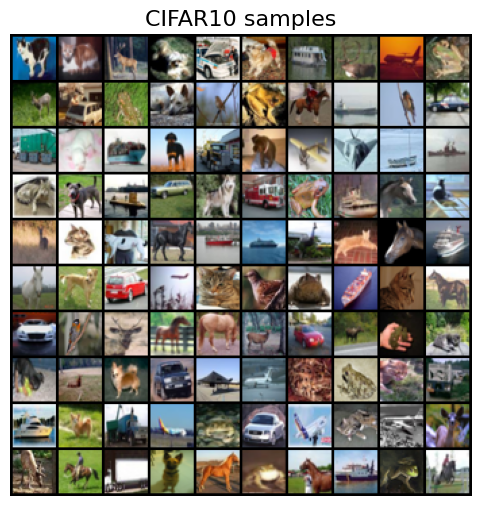

In [9]:
train_data, _, test_data, _ = load_dataset("cifar10", flatten=False, binarize=False)
visualize_images(train_data, "CIFAR10 samples")

Now it is time to define our model. Our model will have the following structure:

* Prior distribution is standard Normal ($p(\mathbf{z}) = \mathcal{N}(0, I)$).
* Variational posterior distribution (or encoder) is $q(\mathbf{z} | \mathbf{x}, \boldsymbol{\phi}) = \mathcal{N}(\boldsymbol{\mu}_{\boldsymbol{\phi}}(\mathbf{x}), \boldsymbol{\Sigma}_{\boldsymbol{\phi}}(\mathbf{x}))$. Here $\boldsymbol{\phi}$ denotes all parameters of the encoder neural network. We will assume that covariance matrice $\boldsymbol{\Sigma}_{\boldsymbol{\phi}}(\mathbf{x})$ is diagonal.
* Generative distribution (or decoder) is $p(\mathbf{x} | \mathbf{z}, \boldsymbol{\theta}) = \mathcal{N}(\boldsymbol{\mu}_{\boldsymbol{\theta}}(\mathbf{z}), \boldsymbol{\Sigma}_{\boldsymbol{\theta}}(\mathbf{z}))$. Here $\boldsymbol{\theta}$ denotes all parameters of the decoder neural network. Please note, that here we will use continuous distribution for our variables $\mathbf{x}$.
* We do not fit the covariance matrix $\boldsymbol{\Sigma}_{\boldsymbol{\theta}}(\mathbf{z})$ in the generative distribution $p(\mathbf{x} | \mathbf{z}, \boldsymbol{\theta})$. We assume that it is identical ($\boldsymbol{\Sigma}_{\boldsymbol{\theta}}(\mathbf{z}) = \mathbf{I}$). We will use the $\boldsymbol{\mu}_{\boldsymbol{\theta}}(\mathbf{z})$ (mean of the generative distribution $p(\mathbf{x} | \mathbf{z}, \boldsymbol{\theta})$) as model samples.
* Our encoder and decoder will be convolutional neural networks.
* Model objective is slightly modified ELBO:
$$
    \mathcal{L}(\boldsymbol{\phi}, \boldsymbol{\theta}) = \mathbb{E}_{q(\mathbf{z} | \mathbf{x}, \boldsymbol{\phi})} \log p(\mathbf{x} | \mathbf{z}, \boldsymbol{\theta}) - \beta * KL (q(\mathbf{z} | \mathbf{x}, \boldsymbol{\phi}) || p(\mathbf{z})).
$$
Here we introduce the parameter $\beta$. It reweights KL term in the total loss. It a standard heuristics that allows to get more accurate model. In this exercise you have to play with it, starting with the value $\beta = 1$ (standard ELBO).

To make the expectation is independent of parameters $\boldsymbol{\phi}$, we will use reparametrization trick.


To calculate the loss, we should derive
- $\log p(\mathbf{x} | \mathbf{z}, \boldsymbol{\theta})$, note that generative distribution is $\mathcal{N}(\boldsymbol{\mu}_{\boldsymbol{\theta}}(\mathbf{z}), \boldsymbol{\Sigma}_{\boldsymbol{\theta}}(\mathbf{z}))$.
- KL between $q(\mathbf{z} | \mathbf{x}, \boldsymbol{\phi}) = \mathcal{N}(\boldsymbol{\mu}_{\boldsymbol{\phi}}(\mathbf{x}), \boldsymbol{\Sigma}_{\boldsymbol{\phi}}(\mathbf{x}))$ and $\mathcal{N}(0, \mathbf{I})$.

Let start with the helper functions.

In [10]:
def get_normal_KL(
    mean_1: torch.Tensor,
    log_std_1: torch.Tensor,
    mean_2: Optional[torch.Tensor] = None,
    log_std_2: Optional[torch.Tensor] = None,
) -> torch.Tensor:
    if mean_2 is None:
        mean_2 = torch.zeros_like(mean_1)
    if log_std_2 is None:
        log_std_2 = torch.zeros_like(log_std_1)
    assert mean_1.shape == log_std_1.shape == mean_2.shape == log_std_2.shape
    # ====
    # your code
    # implement KL(p1 || p2), where
    # p1 = Normal(mean_1, exp(log_std_1) ** 2) and
    # p2 = Normal(mean_2, exp(log_std_2) ** 2)
    # NOTE: we consider the case of diagonal covariance matrix.
    
    # ====
    std_1 = torch.exp(log_std_1)
    std_2 = torch.exp(log_std_2)
    
    kl = log_std_2 - log_std_1 + (std_1**2 + (mean_1 - mean_2)**2) / (2 * std_2**2) - 0.5
    
    return kl


def test_KL():
    assert np.isclose(
        get_normal_KL(
            torch.tensor(2), torch.tensor(3), torch.tensor(0), torch.tensor(0)
        ).numpy(),
        200.2144,
        rtol=1e-3,
    )
    assert np.isclose(
        get_normal_KL(
            torch.tensor(2), torch.tensor(3), torch.tensor(4), torch.tensor(5)
        ).numpy(),
        1.50925,
        rtol=1e-3,
    )
    assert np.allclose(
        get_normal_KL(
            torch.tensor((10, 10)), torch.tensor((2, 4)), torch.tensor((3, 5))
        ).numpy(),
        [49.2990, 1498.479],
        rtol=1e-3,
    )


test_KL()

In [11]:
from math import log, sqrt, pi


def get_normal_nll(x: torch.Tensor, mean: torch.Tensor, log_std: torch.Tensor) -> torch.Tensor:
    # ====
    # your code
    # implement negative log likelihood log p(x)
    # where p(x) = Normal(x | mean, exp(log_std) ** 2)
    # NOTE: we consider the case of diagonal covariance matrix

    # ====
    var = torch.exp(log_std)**2

    return ((x - mean) ** 2) / (2 * var) + log_std + log(sqrt(2 * pi))


def test_NLL():
    assert np.isclose(
        get_normal_nll(torch.tensor(2), torch.tensor(2), torch.tensor(3)).numpy(),
        3.9189,
        rtol=1e-3,
    )
    assert np.isclose(
        get_normal_nll(torch.tensor(5), torch.tensor(-3), torch.tensor(6)).numpy(),
        6.9191,
        rtol=1e-3,
    )
    assert np.allclose(
        get_normal_nll(torch.tensor((10, 10)), torch.tensor((2, 4)), torch.tensor((3, 5))).numpy(),
        np.array([3.9982, 5.9197]),
        rtol=1e-3,
    )


test_NLL()

We are ready to implement VAE model for image dataset.

In [12]:
class ViTVAE(BaseModel):
    def __init__(
        self,
        latent_dim: int,
        num_channels: int,
        image_shape: Tuple[int, int],
        patch_shape: Tuple[int, int],
        embed_dim: int,
        num_heads: int,
        num_layers: int,
        beta: float = 1,
    ) -> None:
        super().__init__()

        self.latent_dim = latent_dim
        self.beta = beta

        self.embed_dim = embed_dim
        self.num_patches = (image_shape[0] // patch_shape[0]) * (image_shape[1] // patch_shape[1])
        # ====
        # your code
        # define here ViT encoder and decoder
        # also implement two linear layers for
        # embddings to latent and latent to embddings projections
        # NOTE: encoder and decoder works in space `num_patches * embed_dim`

        # ====
        self.encoder = ViTEncoder(num_channels=num_channels, image_shape=image_shape, patch_shape=patch_shape, embed_dim=embed_dim, num_heads=num_heads, num_layers=num_layers)
        self.decoder = ViTDecoder(num_channels=num_channels, image_shape=image_shape, patch_shape=patch_shape, embed_dim=embed_dim, num_heads=num_heads, num_layers=num_layers)
        self.latent_proj = nn.Linear(self.num_patches * embed_dim, latent_dim * 2)
        self.embed_proj = nn.Linear(latent_dim, self.num_patches * embed_dim)

    def prior(self, n: int) -> torch.Tensor:
        # ====
        # your code
        # return n samples from prior distribution (we use standart normal for prior)

        # ====

        return torch.randn(n, self.latent_dim)

    def forward(self, x: torch.Tensor) -> tuple:
        # ====
        # your code
        # 1) apply encoder to get mu_z, log_std_z
        # 2) apply reparametrization trick (use self.prior)
        # 3) apply decoder to get mu_x (which corresponds to reconstructed x)

        # ====
        x = self.encoder(x)
        mu_z, log_std_z = self.latent_proj(x.flatten(1, -1)).chunk(2, dim=-1)
        z = self.prior(mu_z.shape[0]).to(self.device) * torch.exp(log_std_z) + mu_z
        x_recon = self.decoder(self.embed_proj(z).reshape(-1, self.num_patches, self.embed_dim))

        return mu_z, log_std_z, x_recon

    def loss(self, x: torch.Tensor) -> dict:
        # ====
        # your code
        # 1) make forward step to get mu_z, log_std_z, x_recon
        # 2) calculate recon_loss (use get_normal_nll)
        # 3) calcucalte kl_loss (use get_normal_KL)

        # ====
        mu_z, log_std_z, x_recon = self(x)
        recon_loss = get_normal_nll(x, x_recon, torch.zeros_like(x)).sum(dim=(1, 2, 3)).mean()
        kl_loss = get_normal_KL(mu_z, log_std_z).sum(dim=-1).mean()

        return {
            "elbo_loss": recon_loss + self.beta * kl_loss,
            "recon_loss": recon_loss,
            "kl_loss": kl_loss,
        }

    def sample(self, n: int) -> np.ndarray:
        with torch.no_grad():
            # ====
            # your code
            # 1) generate prior samples
            # 2) apply decoder

            # ====
            z = self.prior(n).to(self.device)
            x_recon = self.decoder(self.embed_proj(z).reshape(-1, self.num_patches, self.embed_dim))
            samples = torch.clamp(x_recon, -1, 1)
        return samples.cpu().numpy() * 0.5 + 0.5

In [13]:
def newtonschulz5(G, steps=5, eps=1e-7):
    assert G.ndim == 2
    orig_dtype = G.dtype
    a, b, c = (3.4445, -4.7750, 2.0315)
    X = G.bfloat16()
    X /= X.norm() + eps
    if G.size(0) > G.size(1):
        X = X.T
    for _ in range(steps):
        A = X @ X.T
        B = b * A + c * A @ A
        X = a * X + B @ X
    if G.size(0) > G.size(1):
        X = X.T
    return X.to(orig_dtype)


class Muon(torch.optim.Optimizer):
    def __init__(
        self,
        params,
        lr: float = 2e-2,
        beta: float = 0.95,
        weight_decay: float = 0.01,
        ns_steps: int = 5,
    ):
        defaults = dict(lr=lr, beta=beta, weight_decay=weight_decay, ns_steps=ns_steps)
        super().__init__(params, defaults)

    @torch.no_grad()
    def step(self, closure=None):
        for group in self.param_groups:
            lr = group["lr"]
            beta = group["beta"]
            weight_decay = group["weight_decay"]
            ns_steps = group["ns_steps"]
            for p in group["params"]:
                if p.grad is None:
                    continue
                p.mul_(1 - lr * weight_decay)

                state = self.state[p]

                if "momentum" not in state:
                    state["momentum"] = torch.zeros_like(p)

                g = p.grad
                m = state["momentum"]

                if g.ndim == 2:
                    g = newtonschulz5(g, ns_steps)
                elif g.ndim > 2:
                    orig_shape = g.shape
                    g = g.view(g.shape[0], -1)
                    g = newtonschulz5(g, ns_steps)
                    g = g.view(orig_shape)

                m.lerp_(g, 1 - beta)
                g.lerp_(m, beta)
                p.add_(g, alpha=-lr)

That is all! We are ready to train our model.

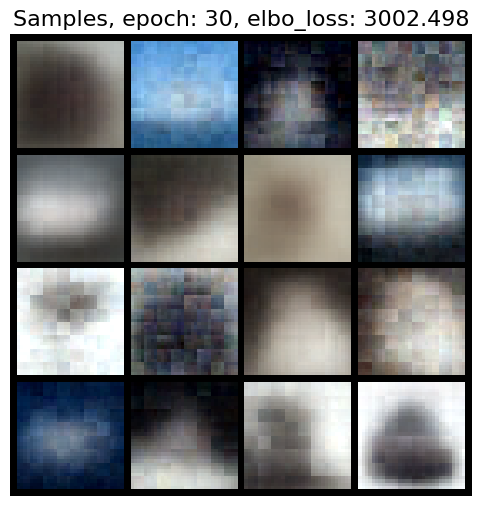

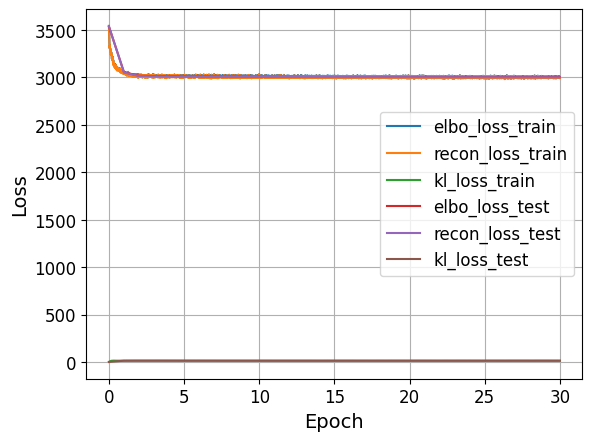

End of the training


In [14]:
# ====
# your code
# choose these parameters
BATCH_SIZE = 256
EPOCHS = 30
LR = 1e-3
LAT_DIM = 4
BETA = 0.2

EMB_DIM = 256
NUM_HEADS = 8
NUM_LAYERS = 4
# ====

# we center the data, because it helps the model to fit
centered_train_data = train_data * 2 - 1
centered_test_data = test_data * 2 - 1

train_loader = data.DataLoader(centered_train_data, batch_size=BATCH_SIZE, shuffle=True)
test_loader = data.DataLoader(centered_test_data, batch_size=BATCH_SIZE)

model = ViTVAE(
    latent_dim=LAT_DIM,
    num_channels=3,
    image_shape=(32, 32),
    patch_shape=(4, 4),
    embed_dim=EMB_DIM, 
    num_heads=NUM_HEADS,
    num_layers=NUM_LAYERS,
    beta=BETA,
)

# choose any optimizer/scheduler as you want
optimizer = Muon(model.parameters(), lr=LR)

train_model(
    model,
    train_loader,
    test_loader,
    epochs=EPOCHS,
    optimizer=optimizer,
    device=DEVICE,
    n_samples=16,
    visualize_samples=True,
    loss_key="elbo_loss"
)

Now we could visualize the model outputs.

1. We could sample new images from our model (sample latent variable from the prior and apply the decoder).
2. We could visualize image reconstructions (apply the encoder and the decoder to the fixed image).
3. Visualize interpolations (apply the encoder to two images $\mathbf{x}_1$ and $\mathbf{x}_2$ to obtain the latent variables $\mathbf{z}_1$ and $\mathbf{z}_2$, apply the decoder to the latent variables $\mathbf{z}$ lying on the segment between $\mathbf{z}_1$ and $\mathbf{z}_2$).

**Note:** it is ok that your samples are blurry. We do not use difficult architectures and do not tune hyperparameters carefully.

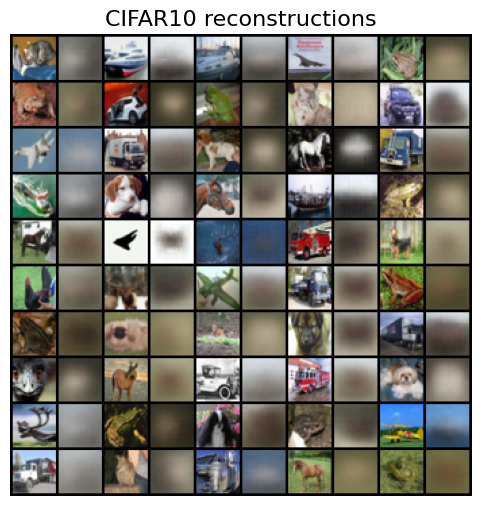

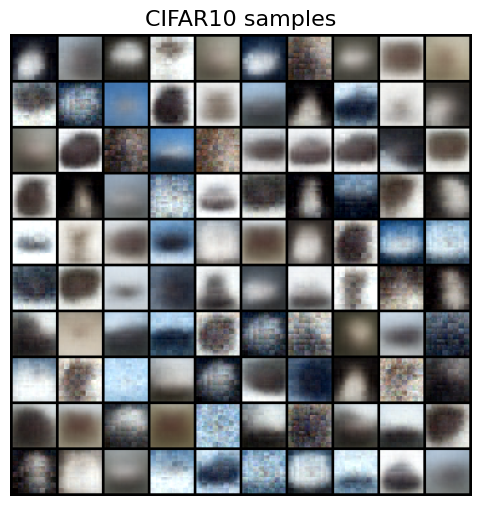

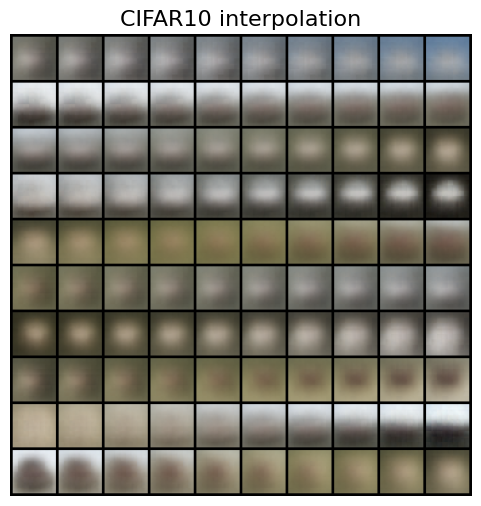

In [15]:
samples = model.sample(100)

x = torch.from_numpy(centered_test_data[:50]).to(model.device)
with torch.no_grad():
    mu_z, _, x_recon = model(x)
    x_recon = torch.clamp(x_recon, -1, 1)
reconstructions = torch.stack((x, x_recon), dim=1).reshape(-1, 3, 32, 32) * 0.5 + 0.5
reconstructions = reconstructions.cpu().numpy()

x = torch.from_numpy(centered_test_data[:20]).to(model.device)
with torch.no_grad():
    embeddings = model.encoder(x)
    z, _ = model.latent_proj(embeddings.flatten(1, -1)).chunk(2, dim=-1)

    embeddings = model.embed_proj(z).reshape(-1, model.num_patches, model.embed_dim)
    embeddings1, embeddings2 = embeddings.chunk(2, dim=0)
    
    interps = [model.decoder(embeddings1 * (1 - alpha) + embeddings2 * alpha) for alpha in np.linspace(0, 1, 10)]
    interps = torch.stack(interps, dim=1).reshape(-1, 3, 32, 32)
    interps = torch.clamp(interps, -1, 1) * 0.5 + 0.5
interps = interps.cpu().numpy()

show_samples(reconstructions, 'CIFAR10 reconstructions')
show_samples(samples, 'CIFAR10 samples')
show_samples(interps, 'CIFAR10 interpolation')

## Task 4: VQ-VAE on CIFAR10 (4 pts)

### Training of VQ-VAE model

In this part you will train [VQ-VAE](https://arxiv.org/abs/1711.00937) model that we have discussed at the lecture (see also [VQ-VAE-2](https://arxiv.org/abs/1906.00446) paper). We will use the same CIFAR10 dataset as in previous task.

VQ-VAE model is a VAE model with discrete latent variable.  

**Reminder:**
* We define  dictionary (word book) space $\{\mathbf{e}_k\}_{k=1}^K$, where $\mathbf{e}_k \in \mathbb{R}^C$, $K$ is the size of the dictionary.
* $\mathbf{z}_e = \text{NN}_e(\mathbf{x}, \boldsymbol{\phi})$ - continuous output of encoder network.
* $\mathbf{z}_q = \mathbf{e}_{k^*}$ is a quantized representation, where $k^* = \text{argmin}_k \| \mathbf{z} - \mathbf{e}_k \|$. It is simple nearest neighbor look up.
* Out deterministic variational posterior:
$$
  q(c = k^* | \mathbf{x}, \boldsymbol{\phi}) = \begin{cases}
  1 , \quad \text{for } k^* = \text{argmin}_k \| \mathbf{z}_e - \mathbf{e}_k \|; \\
  0, \quad \text{otherwise}.
\end{cases}
$$
* Prior distribution is uniform: $p(c) = \text{Uniform}\{1, \dots, K\}$.
* KL divergence between posterior and prior:
$$
  KL(q(c = k^* | \mathbf{x}, \boldsymbol{\phi}), p(c)) = \log K.
$$
* ELBO:
$$
		\mathcal{L} (\boldsymbol{\phi}, \boldsymbol{\theta})  = \mathbb{E}_{q(c | \mathbf{x}, \boldsymbol{\phi})} \log p(\mathbf{x} | \mathbf{e}_{c} , \boldsymbol{\theta}) - \log K =  \log p(\mathbf{x} | \mathbf{z}_q, \boldsymbol{\theta}) - \log K.
$$
* Vector quantization is non-differentiable operation. We will use **straight-through** gradient estimator (we will copy gradients from decoder input $\mathbf{z}_q$ to encoder output $\mathbf{z}_e$.

**Important modifications:**
Due to the straight-through gradient estimation of mapping from $\mathbf{z}_e$ to $\mathbf{z}_q$, the embeddings $\mathbf{e}$ receive no gradients from the ELBO.

Therefore, in order to learn the embedding space we add l2 loss (**codebook loss**) to move the embedding vectors $\mathbf{e}$ towards the encoder outputs $\mathbf{z}_e$.

Finally, since the volume of the embedding space is dimensionless, it can grow arbitrarily if the embeddings $\mathbf{e}$ do not train as fast as the encoder parameters. To make sure the encoder commits to an embedding and its output does not grow, we add a **commitment loss**.

Thus, the total training objective becomes:
$$
  \log p(\mathbf{x}| \mathbf{z}_q, \boldsymbol{\theta}) + \| \text{stop\_gradient}(\mathbf{z}_e) - \mathbf{e}\|_2^2 + \| \mathbf{z}_e - \text{stop\_gradient}(\mathbf{e})\|_2^2.
$$

Pay attention to the $\text{stop\_gradient}(*)$ operator.


Our first step is implement vector quantization procedure. It will also calculate two consistency losses.

In [16]:
class VectorQuantizer(nn.Module):
    def __init__(self, num_embeddings: int = 128, embedding_dim: int = 16, beta: float = 0.25) -> None:
        super().__init__()
        self.embedding_dim = embedding_dim
        self.num_embeddings = num_embeddings

        self.beta = beta

        # Initialize the embeddings which we will quantize.
        self.embedding = nn.Embedding(num_embeddings, embedding_dim)
        self.embedding.weight.data.uniform_(-1 / num_embeddings, 1 / num_embeddings)

    def get_code_indices(self, x: torch.Tensor) -> torch.Tensor:
        input_shape = x.shape[:-1]
        flattened = x.reshape(-1, self.embedding_dim)
        # ====
        # your code
        # 1) calculate distances from flatten inputs to embeddings
        # 2) find nearest embeddings to each input (use argmin op)
        distances = torch.cdist(flattened, self.embedding.weight)

        encoding_indices = torch.argmin(distances, dim=-1)
        # ====
        encoding_indices = encoding_indices.reshape(input_shape)
        return encoding_indices

    def get_quantized(self, encoding_indices: torch.Tensor) -> torch.Tensor:
        # ====
        # your code
        # get embeddgins with appropriate indices

        # ====

        return self.embedding(encoding_indices)

    def forward(self, x: torch.Tensor) -> tuple:
        # ====
        # your code
        # 1) get indices
        # 2) get quantized latents
        # 3) calculate codebook and commitment loss
        #    do not afraid about stop_gradient op
        #    (use .detach() method for quantized latents and x)
        # 4) final loss is codebook_loss + beta * commitment_loss

        # ====

        # Straight-through estimator (think about it!).
        indices = self.get_code_indices(x)
        quantized = self.get_quantized(indices)
        quantized = x + (quantized - x).detach()
        codebook_loss = (quantized.detach() - x).pow(2).mean()
        commitment_loss = (quantized - x.detach()).pow(2).mean()
        loss = codebook_loss + self.beta * commitment_loss

        return quantized, loss


def test_vector_quantizer_tokens():
    x = torch.zeros((4, 16, 32))
    layer = VectorQuantizer(num_embeddings=128, embedding_dim=32)

    indices = layer.get_code_indices(x)
    assert indices.shape == (4, 16), f"get_code_indices(x) returned wrong shape: got {tuple(indices.shape)}, expected (4, 16). Input x shape was {tuple(x.shape)}."

    quantized = layer.get_quantized(indices)
    assert quantized.shape == (4, 16, 32), (
        f"get_quantized(indices) returned wrong shape: got {tuple(quantized.shape)}, expected (4, 16, 32). Indices shape was {tuple(indices.shape)}."
    )

    quantized, loss = layer(x)
    assert quantized.shape == (4, 16, 32), f"layer(x) returned quantized with wrong shape: got {tuple(quantized.shape)}, expected (4, 16, 32). Input x shape was {tuple(x.shape)}."
    assert loss.shape == (), f"layer(x) returned loss with wrong shape: got {tuple(loss.shape)}, expected scalar shape (). Loss type was {type(loss)}."


test_vector_quantizer_tokens()

Now we can define our VQ-VAE model.

In [17]:
class ViTVQVAE(BaseModel):
    def __init__(
        self,
        num_channels: int,
        image_shape: Tuple[int, int],
        patch_shape: Tuple[int, int],
        num_embeddings: int,
        embed_dim: int, 
        num_heads: int,
        num_layers: int,
        recon_loss_scale: float = 1.0,
        beta: float = 0.25,
    ) -> None:
        super().__init__()

        self.recon_loss_scale = recon_loss_scale
        
        self.num_embeddings = num_embeddings
        self.embed_dim = embed_dim
        self.num_patches = (image_shape[0] // patch_shape[0]) * (image_shape[1] // patch_shape[1])
        # ====
        # your code
        # define here ViT encoder and decoder
        # also implement vector quantization layer
        # NOTE: encoder and decoder works in space `num_patches * embed_dim`
        
        # ====
        self.encoder = ViTEncoder(
            num_channels=num_channels,
            image_shape=image_shape,
            patch_shape=patch_shape,
            embed_dim=embed_dim,
            num_heads=num_heads,
            num_layers=num_layers,
        )
        self.decoder = ViTDecoder(
            num_channels=num_channels,
            image_shape=image_shape,
            patch_shape=patch_shape,
            embed_dim=embed_dim,
            num_heads=num_heads,
            num_layers=num_layers,
        )
        self.vq_layer = VectorQuantizer(
            num_embeddings=num_embeddings,
            embedding_dim=embed_dim,
            beta=beta,
        )

    def forward(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        # ====
        # your code
        # 1) apply encoder
        # 2) apply vector quantizer (it returns quantized representation + vq_loss)
        # 3) apply decoder (it returns decoded samples)
        
        # ====
        z = self.encoder(x)
        quantized, vq_loss = self.vq_layer(z)
        decoded = self.decoder(quantized)

        return decoded, vq_loss

    def loss(self, x: torch.Tensor) -> dict:
        # ====
        # your code
        # 1) apply model
        # 2) compute mse loss for reconstruction
        
        # ====
        decoded, vq_loss = self(x)
        recon_loss = F.mse_loss(decoded, x)
        return {
            "total_loss": self.recon_loss_scale * recon_loss + vq_loss,
            "recon_loss": self.recon_loss_scale * recon_loss,
            "vq_loss": vq_loss,
        }

    def get_indices(self, x: torch.Tensor) -> torch.Tensor:
        # ====
        # your code
        # 1) apply encoder
        # 2) get indices of codes using vector quantizer
        
        # ====
        z = self.encoder(x)
        codebook_indices = self.vq_layer.get_code_indices(z)
        return codebook_indices

    def prior(self, n: int) -> torch.Tensor:
        # ====
        # your code
        # prior distribution is uniform
        # 1) get samples from categorical distribution
        # 2) get quantized representations using vector quantizer
        
        # ====
        samples = torch.randint(0, self.num_embeddings, (n, self.num_patches), device=self.device)
        quantized = self.vq_layer.get_quantized(samples)
        return quantized

    def sample(self, n: int) -> np.ndarray:
        with torch.no_grad():
            quantized = self.prior(n)
            samples = self.decoder(quantized)
            samples = torch.clamp(samples, -1, 1)
        return samples.cpu().numpy() * 0.5 + 0.5


def test_vqvae_model():
    model = ViTVQVAE(
        num_channels=1,
        image_shape=(32, 32),
        patch_shape=(8, 8),
        num_embeddings=4,
        embed_dim=128,
        num_heads=1,
        num_layers=1,
    ).cuda()
    x = torch.zeros((2, 1, 32, 32)).cuda()

    indices = model.get_indices(x)
    assert indices.shape == (2, 16), (
        f"model.get_indices(x) returned wrong shape: got {tuple(indices.shape)}, "
        f"expected (2, 16). Input x shape was {tuple(x.shape)}; "
        f"image_shape=(32, 32), patch_shape=(8, 8) implies num_patches=16."
    )

    losses = model.loss(x)
    assert isinstance(losses, dict), (
        f"model.loss(x) should return a dict, got {type(losses)} instead."
    )
    assert "total_loss" in losses, (
        f'model.loss(x) dict is missing key "total_loss". '
        f"Got keys: {list(losses.keys())}."
    )

    quantized = model.prior(10)
    assert quantized.shape == (10, 16, 128), (
        f"model.prior(10) returned wrong shape: got {tuple(quantized.shape)}, "
        f"expected (10, 16, 128). "
        f"Expected (n, num_patches, embed_dim) with n=10, num_patches=16, embed_dim=128."
    )

    decoded = model.decoder(quantized)
    assert decoded.shape == (10, 1, 32, 32), (
        f"model.decoder(quantized) returned wrong shape: got {tuple(decoded.shape)}, "
        f"expected (10, 1, 32, 32). Quantized shape was {tuple(quantized.shape)}."
    )

    sampled = model.sample(10)
    assert sampled.shape == (10, 1, 32, 32), (
        f"model.sample(10) returned wrong shape: got {tuple(sampled.shape)}, "
        f"expected (10, 1, 32, 32). Note: sample() returns a NumPy array."
    )


test_vqvae_model()

Let's train our model!

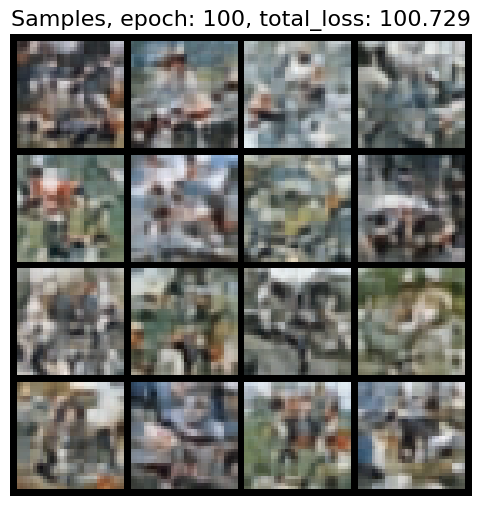

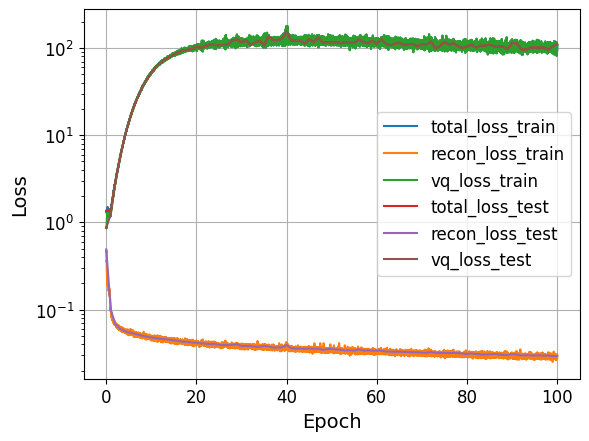

End of the training


In [18]:
# ====
# your code
# choose these parameters
BATCH_SIZE = 256
EPOCHS = 100
LR = 1e-3
RECON_SCALE = 1.0

NUM_EMB = 64
EMB_DIM = 256
NUM_HEADS = 8
NUM_LAYERS = 4
# ====

model = ViTVQVAE(
    num_channels=3,
    image_shape=(32, 32),
    patch_shape=(4, 4),
    num_embeddings=NUM_EMB,
    embed_dim=EMB_DIM, 
    num_heads=NUM_HEADS,
    num_layers=NUM_LAYERS,
    recon_loss_scale=RECON_SCALE
)

# we center the data, because it helps the model to fit
centered_train_data = train_data * 2 - 1
centered_test_data = test_data * 2 - 1

train_loader = data.DataLoader(centered_train_data, batch_size=BATCH_SIZE, shuffle=True)
test_loader = data.DataLoader(centered_test_data, batch_size=BATCH_SIZE)

# choose any optimizer/scheduler as you want
optimizer = Muon(model.parameters(), lr=LR)

train_model(
    model,
    train_loader,
    test_loader,
    epochs=EPOCHS,
    optimizer=optimizer,
    device=DEVICE,
    n_samples=16,
    visualize_samples=True,
    logscale_y=True,
)

Now we are able to sample from the trained model.

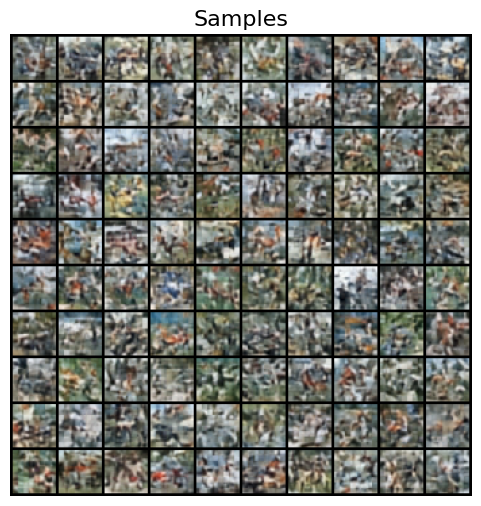

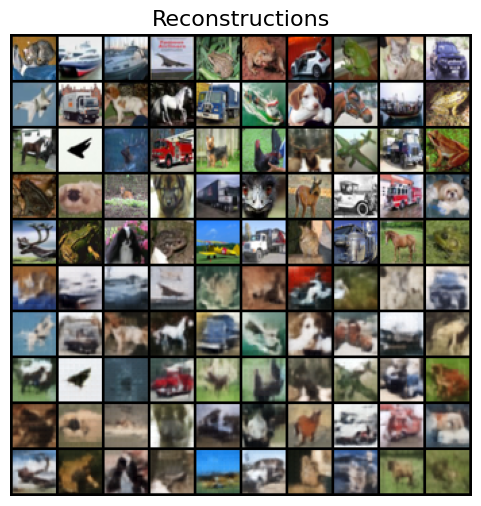

In [19]:
# Samples
samples = model.sample(100)
show_samples(samples, title="Samples")

# Reconstructions
x = torch.from_numpy(centered_test_data[:50]).to(model.device)
with torch.no_grad():
    x_recon, _ = model(x)

x = torch.clamp(x, -1, 1) * 0.5 + 0.5
x_recon = torch.clamp(x_recon, -1, 1) * 0.5 + 0.5

x_recon = x_recon.cpu().numpy()
x = x.cpu().numpy()

reconstructions = np.concatenate((x, x_recon), axis=0)
reconstructions = reconstructions.astype("float32")
show_samples(reconstructions, title="Reconstructions")

Probably you will get bad samples :(

Do not worry, may be it is ok, we will try to fix your samples! Make sure that reconstructions are almost perfect.

### Training of prior autoregressive model

The samples from our VQ-VAE model is not good enough. The authors of the original VQ-VAE paper proposed to train autoregressive model in the latent space after we trained VQ-VAE model.

Remember we have discussed **ELBO surgery** and **aggregrated posterior**. Let recall what do we have in VAE:
* **Training:** we get latent variables $\mathbf{z}$ from variational posterior $q(\mathbf{z} | \mathbf{x}, \boldsymbol{\phi})$ for every object $\mathbf{x}$ and then applies decoder ($p(\mathbf{x} | \mathbf{z}, \boldsymbol{\theta})$). It means that in average decoder is applied to the latent variables from aggregated posterior $q_{\text{agg}}(\mathbf{z} | \boldsymbol{\phi})$.
* **Inference:** We apply decoder to the latent variables from prior distribution $p(\mathbf{z})$.

It means that if our aggregated posterior $q_{\text{agg}}(\mathbf{z} | \boldsymbol{\phi})$ and prior $p(\mathbf{z})$ is too far from each other, then we get inconsistency.

So let train to remove this inconsistency. To be concrete, let train (autoregressive) model in the latent space that will try to predict samples from the aggregated posterior $q_{\text{agg}}(\mathbf{z} | \boldsymbol{\phi})$.

We will use a **GPT model**. Let us begin with masked multi-head attention, whose implementation is similar to the one introduced in Homework 1.

**NOTE:** In this homework we assme `batch_first=True`, make fixes accordingly.

In [20]:
class MultiheadAttention(nn.MultiheadAttention):
    def __init__(
        self, 
        embed_dim: int, 
        num_heads: int, 
        batch_first: bool = True
    ) -> None:
        super().__init__(embed_dim, num_heads, batch_first=batch_first)

    def get_attention_mask(self, x: torch.Tensor) -> torch.Tensor:
        # ====
        # your code
        # define attention mask, it should contain
        # 1) zeros under and on the main diagonal
        # 2) minus Inf above the main diagonal
        
        attention_mask = torch.full((x.shape[1], x.shape[1]), -float('inf'), device=x.device)
        attention_mask = torch.triu(attention_mask, diagonal=1)
        # ====
        return attention_mask

    def forward(
        self, 
        query: torch.Tensor,
        key: torch.Tensor,
        value: torch.Tensor,
        key_padding_mask: Optional[torch.Tensor] = None,
        need_weights: bool = True,
        attn_mask: Optional[torch.Tensor] = None,
        average_attn_weights: bool = True,
        is_causal: bool = False
    ) -> Tuple[torch.Tensor, ...]:
        mask = self.get_attention_mask(query)
        return super().forward(
            query, key, value,
            attn_mask=mask,
            key_padding_mask=key_padding_mask,
            need_weights=need_weights,
            average_attn_weights=average_attn_weights,
            is_causal=is_causal
        )


def test_attention_mask() -> None:
    x = torch.zeros(4, 2, 16)
    mask = np.array([[0.0, -np.inf], [0.0, 0.0]])
    layer = MultiheadAttention(16, 8)
    attention_mask = layer.get_attention_mask(x)

    assert attention_mask.size() == (x.shape[1], x.shape[1]), \
        "Attention mask must be square with shape (seq_len, seq_len)."

    assert np.allclose(attention_mask.detach().cpu().numpy(), mask), \
        "Mask must be 0 on/under diagonal and -inf strictly above diagonal."

    out, _ = layer(x, x, x, need_weights=False)

    assert x.size() == out.size(), \
        "MultiheadAttention output must have the same shape as the input (seq_len, batch_size, embed_dim)."


test_attention_mask()

In [ ]:
class GPT(BaseModel):
    def __init__(
        self, 
        dim: int, 
        num_embeddings: int, 
        embed_dim: int, 
        num_heads: int, 
        num_layers: int
    ) -> None:
        super().__init__()

        self.dim = dim
        self.num_embeddings = num_embeddings
        self.embed_dim = embed_dim
        self.criterion = nn.CrossEntropyLoss()

        self.sos = nn.Parameter(0.02 * torch.randn(embed_dim))
        
        self.token_embeddings = nn.Embedding(num_embeddings, embed_dim)
        self.position_embeddings = nn.Embedding(dim, embed_dim)

        self.transformers = nn.ModuleList([
            TransformerBlock(
                embed_dim=embed_dim, 
                num_heads=num_heads, 
                attention_class=MultiheadAttention
            ) for _ in range(num_layers)
        ])
        
        self.ln_final = nn.LayerNorm(embed_dim)
        self.linear_final = nn.Linear(embed_dim, num_embeddings, bias=False)

    def add_sos_token(self, embeddings: torch.Tensor) -> torch.Tensor:
        batch_size = embeddings.shape[0]
        sos_tokens = self.sos.view(1, 1, -1).repeat(batch_size, 1, 1)
        return torch.cat([sos_tokens, embeddings[:, :-1, :]], dim=1)

    def add_pos_embeddings(self, embeddings: torch.Tensor) -> torch.Tensor:
        positions = torch.arange(embeddings.shape[1], device=embeddings.device)
        pos_emb = self.position_embeddings(positions)
        return embeddings + pos_emb.unsqueeze(0)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.token_embeddings(x.to(torch.long))
        x = self.add_sos_token(x)
        x = self.add_pos_embeddings(x)

        for block in self.transformers:
            x = block(x)
        x = self.ln_final(x)
        logits = self.linear_final(x)
        return logits

    def loss(self, x: torch.Tensor) -> dict:
        logits = self(x)
        loss = self.criterion(logits.reshape(-1, self.num_embeddings), x.reshape(-1).long())
        return {"total_loss": loss}

    @torch.no_grad()
    def sample(self, n_samples: int) -> np.ndarray:
        samples = torch.zeros(
            n_samples, self.dim, dtype=torch.long, device=self.device
        )
        for i in range(self.dim):
            logits = self(samples)
            dist = torch.distributions.Categorical(logits=logits[:, i, :])
            samples[:, i] = dist.sample()
        return samples.cpu().numpy()

def test_gpt():
    batch_size, dim = 8, 2
    embed_dim = 12
    num_embeddings = 256

    gpt = GPT(
        dim=dim,
        num_embeddings=num_embeddings,
        embed_dim=embed_dim,
        num_heads=4,
        num_layers=2,
    )

    emb = torch.randn(batch_size, dim, embed_dim)
    out = gpt.add_sos_token(emb)

    assert torch.isclose(out[:, 0, :], gpt.sos).all(), \
        "First token must equal the SOS embedding for every batch element."
    assert torch.allclose(out[:, 1:, :], emb[:, :-1, :]), \
        "Sequence must be shifted right by 1."

    with torch.no_grad():
        for p in range(dim):
            gpt.position_embeddings.weight[p].fill_(float(p))

    emb = torch.zeros(batch_size, dim, embed_dim)
    out = gpt.add_pos_embeddings(emb)

    for p in range(dim):
        expected = torch.full((batch_size, embed_dim), p, dtype=emb.dtype)
        assert torch.allclose(out[:, p, :], expected), (
            f"Position {p} must add a vector filled with {p} to all batch elements."
        )

    x = torch.randint(0, num_embeddings, size=(batch_size, dim))
    assert gpt(x).shape == torch.Size([batch_size, dim, num_embeddings]), \
        "Output must have shape (batch_size, seq_len, 256) for 256-class pixels."

test_gpt()

Now let’s prepare the indices dataset.

In [22]:
# please be careful if you have changed path_shape!
LATENT_DIM = 64 
# ====
# your code
# you have to get indices of the emdeddings from the VQ-VAE model for train and test data

# ====
train_indices = []
test_indices = []
BATCH_SIZE = 256

model.eval()
with torch.no_grad():
    for batch in train_loader:
        z = model.encoder(batch.to(model.device))
        train_indices.append(model.vq_layer.get_code_indices(z).numpy(force=True))

    for batch in test_loader:
        z = model.encoder(batch.to(model.device))
        test_indices.append(model.vq_layer.get_code_indices(z).numpy(force=True))

train_indices = np.concatenate(train_indices, axis=0)
test_indices = np.concatenate(test_indices, axis=0)

assert isinstance(train_indices, np.ndarray)
assert isinstance(test_indices, np.ndarray)
assert train_indices.shape == (50000, LATENT_DIM), f'Wrong shapes: {tuple(train_indices.shape)} vs {(50000, LATENT_DIM)}'
assert test_indices.shape == (10000, LATENT_DIM), f'Wrong shapes: {tuple(test_indices.shape)} vs {(10000, LATENT_DIM)}'

Now we are ready to train our model.

Epoch: 20, loss: 2.6165167154098046


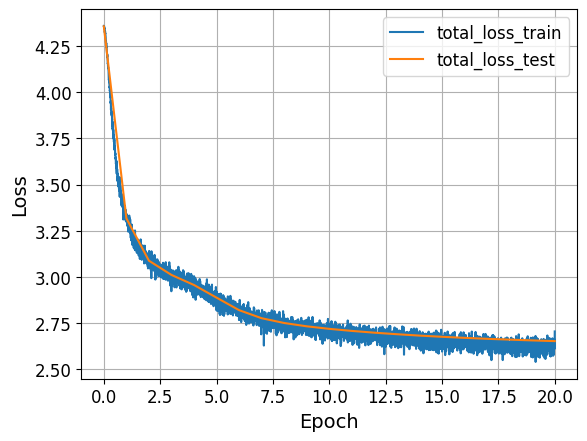

End of the training


In [23]:
# ====
# your code
# choose these parameters
EPOCHS = 20
BATCH_SIZE = 256
LR = 1e-3

EMB_DIM = 256
NUM_HEADS = 8
NUM_LAYERS = 5
# ====

prior_model = GPT(
    dim=LATENT_DIM, 
    num_embeddings=NUM_EMB, 
    embed_dim=EMB_DIM, 
    num_heads=NUM_HEADS, 
    num_layers=NUM_LAYERS
)

train_loader = data.DataLoader(train_indices, batch_size=BATCH_SIZE, shuffle=True)
test_loader = data.DataLoader(test_indices, batch_size=BATCH_SIZE)

# choose any optimizer/scheduler as you want
optimizer = Muon(prior_model.parameters(), lr=LR)

train_model(
    prior_model,
    train_loader,
    test_loader,
    epochs=EPOCHS,
    optimizer=optimizer,
    device=DEVICE,
    visualize_samples=False,
    use_amp=True
)

Now we are ready to sample from our VQ-VAE model. The difference here that we will sample our embedding indices from the GPT prior model instead of the Uniform prior distribution.

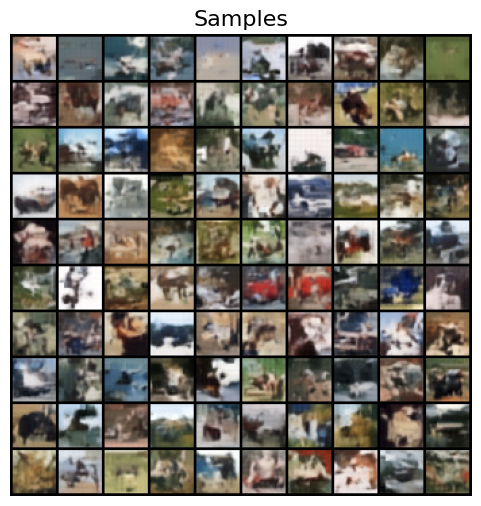

In [25]:
N_SAMPLES = 100
indices = prior_model.sample(N_SAMPLES)
with torch.no_grad():
    quantized = model.vq_layer.get_quantized(
        torch.from_numpy(indices).cuda()
    )
    samples = 0.5 * torch.clamp(
        model.decoder(quantized), -1, 1
    ) + 0.5
    samples = samples.cpu().numpy()

samples = samples.astype("float32")
show_samples(samples, title="Samples")